# Hypothesis 6: the quality–cost trade-off is acceptable

We measure downstream accuracy, fit plus transform wall-clock time, Python allocation peak, serialized state size, and output size for matched-dimensional representations. This is a cost profile, not a claim that one cost envelope is acceptable for every application.

In [1]:
import sys
import time
import tracemalloc
from pathlib import Path
notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists(): notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))
import matplotlib.pyplot as plt
import pandas as pd
from _hypothesis_utils import classification_data, classification_score, downstream_classifier, forest_sketch, initial_projection, serialized_size_mb

,accuracy,errors,wall_seconds,cpu_seconds,peak_python_mb,serialized_state_mb,output_mb
method,,,,,,,
original,0.620,167,1.512,5.108,1.445,0.005,1.208
initial random projection,0.611,171,3.093,10.359,0.737,0.007,0.322
Forest Sketch,0.605,174,5.403,14.997,30.406,6.305,0.322


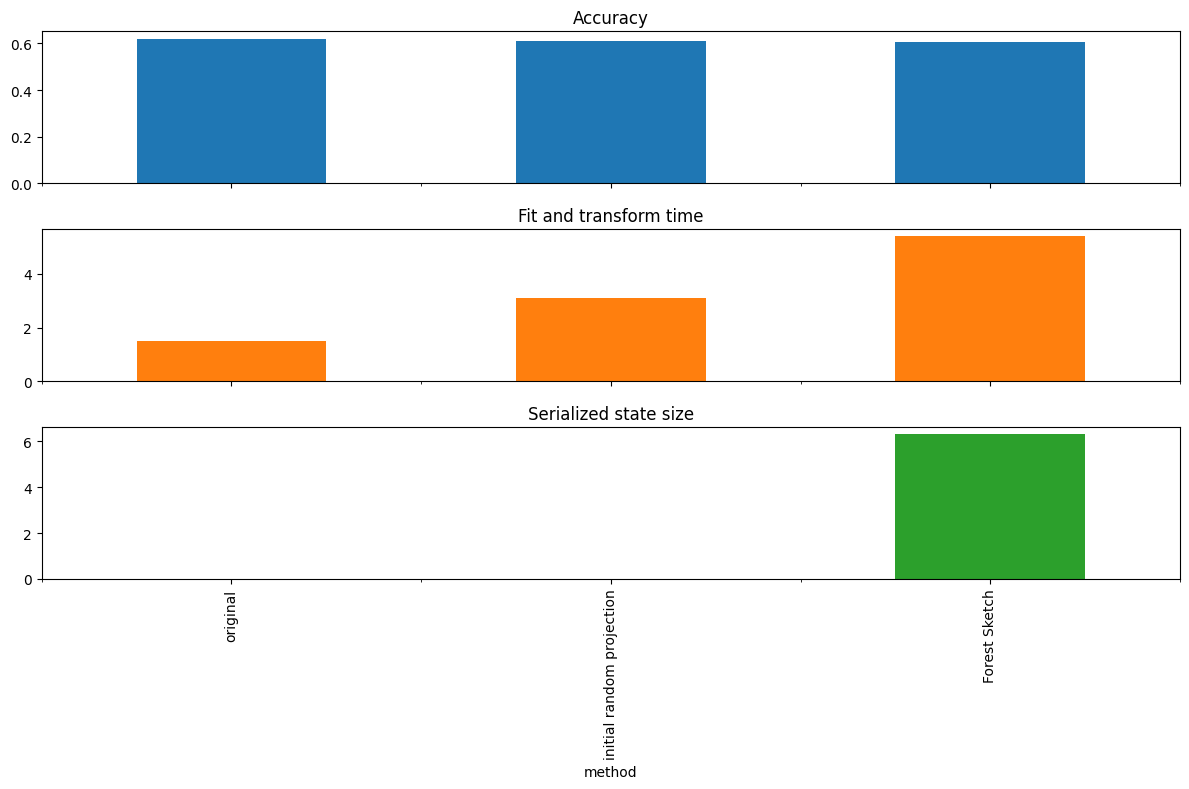

Hypothesis 6: NOT SUPPORTED under this exploratory cost envelope — accuracy difference=-0.016


In [2]:
X_train, _, X_test, y_train, _, y_test = classification_data(0)
X_train_0, X_test_0, initial_projector = initial_projection(X_train, X_test, 32, 0)
cases = [('original', None, X_train, X_test), ('initial random projection', initial_projector, X_train_0, X_test_0), ('Forest Sketch', forest_sketch(0, 32, 2), None, None)]
rows = []
for name, representation, train_view, test_view in cases:
    tracemalloc.start()
    start_wall = time.perf_counter()
    start_cpu = time.process_time()
    if representation is not None and name == 'Forest Sketch':
        train_view = representation.fit_transform(X_train, y_train)
        test_view = representation.transform(X_test)
    predictor = downstream_classifier(0).fit(train_view, y_train)
    wall_seconds = time.perf_counter() - start_wall
    cpu_seconds = time.process_time() - start_cpu
    _, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    accuracy, errors = classification_score(predictor, train_view, y_train, test_view, y_test)
    state = (representation, predictor)
    rows.append({'method': name, 'accuracy': accuracy, 'errors': errors, 'wall_seconds': wall_seconds, 'cpu_seconds': cpu_seconds, 'peak_python_mb': peak_bytes / 2**20, 'serialized_state_mb': serialized_size_mb(state), 'output_mb': train_view.nbytes / 2**20})
results = pd.DataFrame(rows).set_index('method')
display(results.round(3))
ax = results[['accuracy', 'wall_seconds', 'serialized_state_mb']].plot.bar(subplots=True, figsize=(12, 8), legend=False, title=['Accuracy', 'Fit and transform time', 'Serialized state size'])
plt.tight_layout()
plt.show()
gain = results.loc['Forest Sketch', 'accuracy'] - results.loc['original', 'accuracy']
print(f'Hypothesis 6: {"SUPPORTED" if gain > 0 else "NOT SUPPORTED"} under this exploratory cost envelope — accuracy difference={gain:.3f}')

## Conclusion

**Hypothesis:** any predictive gain is large enough to justify Forest Sketch's additional fitting, path extraction, memory, and model-size cost.

**Experiment:** profile original features, initial projection, and two-iteration Forest Sketch on the same difficult classification task at `d=32`.

**Measure:** held-out accuracy and integer errors; wall-clock and CPU time; peak Python allocation; serialized state size; and representation size.

**Result:** not supported under this exploratory cost envelope: Forest Sketch accuracy was 0.016 below the original-feature baseline while adding computation and state.